
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [8]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/Mekong_GLOBCOVER_L4.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 6227, 'height': 8247, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.002777777777777778, 0.0, 92.17361111111111,
       0.0, -0.002777777777777778, 28.540277777777767)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


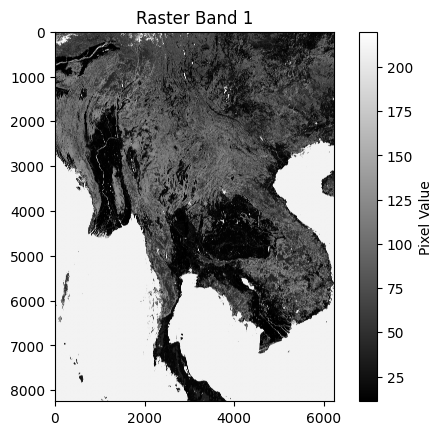

In [9]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

raster_path = "/content/drive/MyDrive/GEE_Exports_4Band/sentinel2_4band_image.tif"

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    print("Metadata of the opened raster file:")
    print(dataset.meta)
    # เมื่อ export จาก GEE ด้วย multiBandImage = ee.Image.cat([red, green, nir, ndvi]);
    # Band 1: Red, Band 2: Green, Band 3: NIR, Band 4: NDVI
    red = dataset.read(1).astype(float)  # ช่อง Red (Band 1)
    nir = dataset.read(3).astype(float)  # ช่อง NIR (Band 3)

# คำนวณ NDVI
# Note: If the 4th band is already pre-calculated NDVI, you could also read that directly:
# ndvi = dataset.read(4).astype(float)
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()

Metadata of the opened raster file:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 11384, 'height': 11116, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 99.92374130292133,
       0.0, -8.983152841195215e-05, 14.471140574938195)}



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [1]:
import numpy as np
import rasterio

# กำหนด path ของไฟล์ raster ต้นฉบับที่ใช้คำนวณ NDVI
raster_path = "/content/drive/MyDrive/GEE_Exports_4Band/sentinel2_4band_image.tif"

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"

with rasterio.open(raster_path) as src:
    # อ่านข้อมูลแบนด์ Red และ NIR
    # Band 1: Red, Band 2: Green, Band 3: NIR, Band 4: NDVI (จาก GEE script)
    red = src.read(1).astype(float)  # ช่อง Red (Band 1)
    nir = src.read(3).astype(float)  # ช่อง NIR (Band 3)

    # คำนวณ NDVI
    ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

    # อัปเดตโปรไฟล์สำหรับไฟล์ NDVI ที่จะบันทึก
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1) # NDVI เป็น float32 และมี 1 แบนด์

    # บันทึกไฟล์ NDVI
    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print(f"บันทึกไฟล์ NDVI ไปที่ '{ndvi_output}' เรียบร้อย!")

บันทึกไฟล์ NDVI ไปที่ 'ndvi_output.tif' เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [22]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "/content/drive/MyDrive/shapefile/tambol.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")


ตัดข้อมูล Raster สำเร็จ!


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


### **แบบฝึกหัด 1**: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3613 (\N{THAI CHARACTER FO FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3638 (\N{THAI CHARACTER SARA UE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

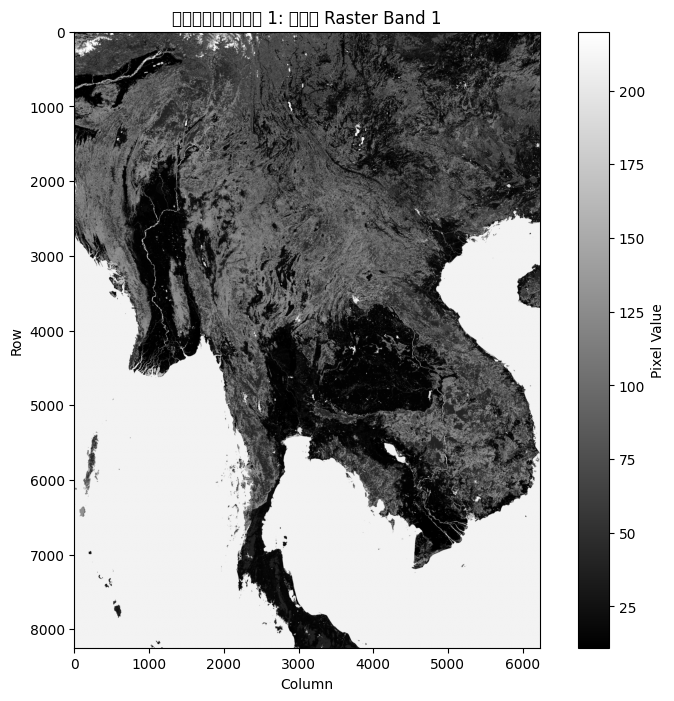

In [25]:
import rasterio
import matplotlib.pyplot as plt

raster_path_exercise = "/content/Mekong_GLOBCOVER_L4.tif"

with rasterio.open(raster_path_exercise) as dataset:
    band1_exercise = dataset.read(1)

plt.figure(figsize=(10, 8))
plt.imshow(band1_exercise, cmap='gray')
plt.colorbar(label='Pixel Value')
plt.title('แบบฝึกหัด 1: ภาพ Raster Band 1')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

### **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [29]:
import rasterio

raster_path_exercise = "/content/Mekong_GLOBCOVER_L4.tif"

with rasterio.open(raster_path_exercise) as dataset:
    print("ข้อมูลเมตาของภาพ Raster (แบบฝึกหัด 2):")
    print(dataset.meta)

ข้อมูลเมตาของภาพ Raster (แบบฝึกหัด 2):
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 6227, 'height': 8247, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.002777777777777778, 0.0, 92.17361111111111,
       0.0, -0.002777777777777778, 28.540277777777767)}


### คำอธิบายข้อมูล

*   driver: รูปแบบของไฟล์ Raster เช่น 'GTiff' (GeoTIFF).
*   dtype: ประเภทข้อมูลของพิกเซล เช่น 'uint8' (จำนวนเต็ม 8 บิต), 'float32' (ทศนิยม 32 บิต).
*  nodata: ค่าที่ใช้แทนข้อมูลที่ไม่มีอยู่หรือไม่ถูกต้อง (NoData value) ซึ่งจะถูกละเว้นในการวิเคราะห์.
*   width: จำนวนคอลัมน์ของพิกเซลในภาพ Raster.
*   height: จำนวนแถวของพิกเซลในภาพ Raster.
*   count: จำนวนแบนด์ (band) หรือช่องสัญญาณในภาพ Raster (เช่น 1 สำหรับภาพขาวดำ, 3 สำหรับภาพสี RGB).
*   crs: Coordinate Reference System (ระบบพิกัดอ้างอิง) ที่ใช้สำหรับข้อมูลทางภูมิศาสตร์ เช่น WGS 84 (EPSG:4326).
*   transform: Affine transformation matrix ที่ใช้อธิบายความสัมพันธ์ระหว่างพิกัดภาพ (row, col) กับพิกัดทางภูมิศาสตร์ (x, y) ซึ่งประกอบด้วยค่าความละเอียดของพิกเซลและการอ้างอิงตำแหน่งของภาพค่ะ

### **แบบฝึกหัด 3**: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# กำหนด path ของไฟล์ภาพดาวเทียมที่มีแบนด์ Red และ NIR
raster_path_exercise_ndvi = "/content/drive/MyDrive/GEE_Exports_4Band/sentinel2_4band_image.tif"

with rasterio.open(raster_path_exercise_ndvi) as dataset:
    red = dataset.read(1).astype(float)
    nir = dataset.read(3).astype(float)

# คำนวณ NDVI
ndvi_exercise = (nir - red) / (nir + red + 1e-10)

# แสดงผลแผนที่ NDVI
plt.figure(figsize=(10, 8))
plt.imshow(ndvi_exercise, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI Value')
plt.title('Normalized Difference Vegetation Index (NDVI) อีกครั้ง')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

### **แบบฝึกหัด 4**: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

อ่าน Shapefile จาก '/content/drive/MyDrive/shapefile/tambol.shp' สำเร็จ
แบบฝึกหัด 4: ตัดข้อมูล Raster สำเร็จ! บันทึกไฟล์ไปที่ 'clipped_exercise_output.tif'


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3606 (\N{THAI CHARACTER THO THUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3613 (\N{THAI CHARACTER FO FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io,

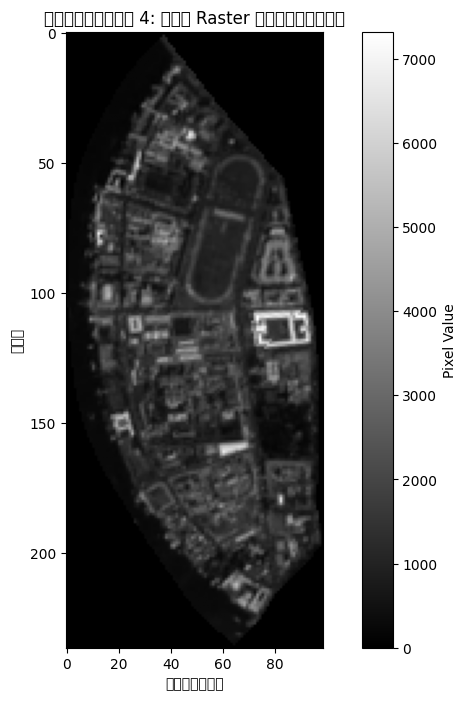

In [3]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import rasterio

shapefile_path_exercise = "/content/drive/MyDrive/shapefile/tambol.shp"

raster_path_exercise_clip = "/content/drive/MyDrive/GEE_Exports_4Band/sentinel2_4band_image.tif"

try:
    gdf_exercise = gpd.read_file(shapefile_path_exercise)
    print(f"อ่าน Shapefile จาก '{shapefile_path_exercise}' สำเร็จ")
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการอ่าน Shapefile: {e}")
    print("โปรดตรวจสอบว่าไฟล์ .shp และไฟล์ประกอบอื่นๆ (เช่น .shx, .dbf) อยู่ครบถ้วนในโฟลเดอร์เดียวกัน")
    gdf_exercise = None

if gdf_exercise is not None and not gdf_exercise.empty:

    geometry_exercise = [mapping(gdf_exercise.geometry.iloc[0])]


    with rasterio.open(raster_path_exercise_clip) as src:
        out_image_exercise, out_transform_exercise = mask(src, geometry_exercise, crop=True)
        out_meta_exercise = src.meta.copy()


    out_meta_exercise.update({"height": out_image_exercise.shape[1],
                              "width": out_image_exercise.shape[2],
                              "transform": out_transform_exercise})

    clipped_raster_output_exercise = "clipped_exercise_output.tif"
    with rasterio.open(clipped_raster_output_exercise, "w", **out_meta_exercise) as dest:
        dest.write(out_image_exercise)

    print(f"แบบฝึกหัด 4: ตัดข้อมูล Raster สำเร็จ! บันทึกไฟล์ไปที่ '{clipped_raster_output_exercise}'")


    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 8))
    plt.imshow(out_image_exercise[0], cmap='gray')
    plt.colorbar(label='Pixel Value')
    plt.title('แบบฝึกหัด 4: ภาพ Raster ที่ถูกตัด')
    plt.xlabel('คอลัมน์')
    plt.ylabel('แถว')
    plt.show()
else:
    print("ไม่สามารถดำเนินการตัดภาพได้ เนื่องจากไม่สามารถโหลด Shapefile ได้อย่างถูกต้อง")